# Actividad — Sesión 3: Del dato crudo al dataset listo
### Ingestión y preparación de datos · Inteligencia Artificial (FP13)
**Nombre:** Camilo Guzman Arias  **Matrícula:** 4949514  **Fecha:** 11/09/26

---
### Instrucciones
Trabajas con los **mismos 4 archivos** de la clase (`flota_norteamerica.csv`, `flota_europa.xlsx`,
`flota_asia.txt`, `flota_datalake.parquet`), que deben estar en la **misma carpeta** que este
notebook. Completa cada bloque marcado con `# TODO`. Responde también las **preguntas de análisis**
(celdas de texto). 

**Entrega (hoy mismo):** sube a *Canvas* el link de github a este notebook ejecutado (menú *Kernel → Restart &
Run All* sin errores) con nombre `S3_ApellidoNombre.ipynb`.

**Objetivo:** dejar el dataset **consolidado, limpio y enriquecido** para responder la pregunta:
*¿qué características del powertrain determinan el consumo (L/100 km) de un vehículo?*


## Librerías

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

## Parte 1 · Ingestión y consolidación  *(2 pts)*
Lee cada archivo con la función adecuada y únelos en un solo DataFrame `df`.
Recuerda: el TXT usa separador `~` y marca los faltantes con `?`.

In [10]:
# TODO: lee las 4 fuentes
df_csv = pd.read_csv("flota_norteamerica.csv")
df_xls = pd.read_excel("flota_europa.xlsx", sheet_name="registros")
df_txt = pd.read_csv("flota_asia.txt", sep="~", na_values="?")
df_pq = pd.read_parquet("flota_datalake.parquet")

# TODO: consolida en un solo DataFrame
df = pd.concat([df_csv, df_xls, df_txt, df_pq], ignore_index=True)

print("Consolidado ->", df.shape)  # se espera (410, 9)

Consolidado -> (410, 9)


## Parte 2 · Limpieza básica  *(2 pts)*
1. Reporta cuántos **duplicados** hay y elimínalos.
2. Reporta cuántos **faltantes** hay en `horsepower` e **imputa** con la mediana.

In [11]:
# TODO: duplicados
print('Duplicados:', df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)

# TODO: faltantes en horsepower
print('Faltantes horsepower:', df['horsepower'].isna().sum())
df['horsepower'] = df['horsepower'].fillna(df['horsepower'].median())

print('Filas finales:', len(df), '| Faltantes HP:', df['horsepower'].isna().sum())

Duplicados: 12
Faltantes horsepower: 6
Filas finales: 398 | Faltantes HP: 0


## Parte 3 · Mapeos y unidades métricas  *(1.5 pts)*
1. Crea la columna `region` mapeando `origin` (1=EUA, 2=Europa, 3=Japón).
2. Crea `peso_kg` (1 lb = 0.453592 kg).
3. Crea `consumo_L_100km` a partir de `mpg` (fórmula: `235.215 / mpg`).

In [12]:
# TODO: región
df["region"] = df["origin"].map({1: "EUA", 2: "Europa", 3: "Japón"})

# TODO: peso en kg
df["peso_kg"] = df["weight"] * 0.453592

# TODO: consumo en L/100km
df["consumo_L_100km"] = 235.215 / df["mpg"]

df[["name", "region", "peso_kg", "consumo_L_100km"]].head()

,name,region,peso_kg,consumo_L_100km
0,chevrolet chevelle malibu,EUA,1589.386368,13.067500
1,buick skylark 320,EUA,1675.115256,15.681000
2,plymouth satellite,EUA,1558.542112,13.067500
3,amc rebel sst,EUA,1557.181336,14.700938
4,ford torino,EUA,1564.438808,13.836176


## Parte 4 · Extracción e ingeniería de características  *(2 pts)*
1. Extrae la **marca** (primer token de `name`). Corrige al menos: `chevy`/`chevroelt`→`chevrolet`,
   `toyouta`→`toyota`, `vw`/`vokswagen`→`volkswagen`.
2. Crea la característica `relacion_pot_peso` = `horsepower / peso_kg`.
3. **Diseña tú una característica nueva** con sentido automotriz (por ejemplo, peso por cilindro,
   una bandera `es_importado`, etc.) y explícala en la celda de texto.

In [13]:
# TODO: marca normalizada
correcciones = {
    "chevy": "chevrolet",
    "chevroelt": "chevrolet",
    "toyouta": "toyota",
    "vw": "volkswagen",
    "vokswagen": "volkswagen",
}
df["marca"] = df["name"].str.split().str[0].replace(correcciones)

# TODO: relación potencia-peso
df["relacion_pot_peso"] = df["horsepower"] / df["peso_kg"]

# TODO: TU característica nueva (ej. peso por cilindro)
df["mi_feature"] = df["peso_kg"] / df["cylinders"]

df[["name", "marca", "relacion_pot_peso", "mi_feature"]].head()

,name,marca,relacion_pot_peso,mi_feature
0,chevrolet chevelle malibu,chevrolet,0.081793,198.673296
1,buick skylark 320,buick,0.098501,209.389407
2,plymouth satellite,plymouth,0.096244,194.817764
3,amc rebel sst,amc,0.096328,194.647667
4,ford torino,ford,0.089489,195.554851


**✍️ Explica tu característica nueva** (2–3 líneas: qué mide y por qué podría ayudar a predecir el consumo):

_(escribe aquí tu respuesta)_

## Parte 5 · Análisis de correlación  *(2 pts)*
1. Calcula la matriz de correlación de las variables numéricas relevantes.
2. Grafica el **mapa de calor**.
3. Identifica un **par altamente correlacionado** (`|r| > 0.9`) y decide cuál conservar.

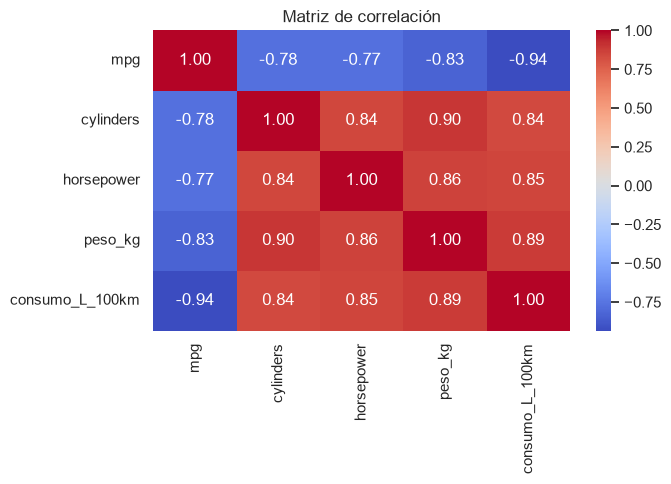

In [14]:
num = ["mpg", "cylinders", "horsepower", "peso_kg", "consumo_L_100km"]
corr = df[num].corr()

# TODO: mapa de calor con seaborn (usa annot=True, cmap='coolwarm')
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

**✍️ Pregunta de análisis:** menciona **un par** de variables con `|r| > 0.9`, indica cuál
**eliminarías** y **justifica** por qué (2–3 líneas):

_(escribe aquí tu respuesta)_

## Cierre  *(reporte, 0.5 pts)*
Muestra la forma final del dataset y sus columnas.

In [15]:
print('Dataset final:', df.shape)
print('Columnas:', list(df.columns))
df.head()

Dataset final: (398, 15)
Columnas: ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin', 'name', 'region', 'peso_kg', 'consumo_L_100km', 'marca', 'relacion_pot_peso', 'mi_feature']


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name,region,peso_kg,consumo_L_100km,marca,relacion_pot_peso,mi_feature
0,18.0,8,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu,EUA,1589.386368,13.067500,chevrolet,0.081793,198.673296
1,15.0,8,350.0,165.0,3693,11.5,70,1,buick skylark 320,EUA,1675.115256,15.681000,buick,0.098501,209.389407
2,18.0,8,318.0,150.0,3436,11.0,70,1,plymouth satellite,EUA,1558.542112,13.067500,plymouth,0.096244,194.817764
3,16.0,8,304.0,150.0,3433,12.0,70,1,amc rebel sst,EUA,1557.181336,14.700938,amc,0.096328,194.647667
4,17.0,8,302.0,140.0,3449,10.5,70,1,ford torino,EUA,1564.438808,13.836176,ford,0.089489,195.554851


Un par con una correlación superior a 0.9 es peso_kg y consumo_L_100km (o bien mpg). Eliminaría consumo_L_100km porque es una transformación matemática directa de mpg y aporta información redundante al modelo, evitando problemas de multicolinealidad sin perder variabilidad real de los datos.

---
### Rúbrica (10 pts)
| Parte | Criterio | Pts |
|---|---|---|
| 1 | Lee los 4 formatos correctamente y consolida (410 filas) | 2.0 |
| 2 | Elimina 12 duplicados e imputa faltantes con mediana | 2.0 |
| 3 | Mapeos de región y conversiones métricas correctas | 1.5 |
| 4 | Marca normalizada + feature propia con justificación | 2.0 |
| 5 | Heatmap correcto + par redundante bien justificado | 2.0 |
| Cierre | Notebook corre completo sin errores (*Run All*) | 0.5 |
| | **Total** | **10** |

<br>

> Se evalúa que el notebook **corra de principio a fin sin errores** y que las **respuestas de
> análisis** estén redactadas con criterio de ingeniería.
